# Input embedding networks reference notebook

Demonstrates the per-timestep input embedding networks in `src/models/embeddings.py`
(`EmbeddingNetwork`) — the single class for this now. Embeddings are a *Forecaster*-level
concern, not a model concern: an `EmbeddingNetwork` is constructed with settings only
(no weights yet), handed to `Forecaster(..., embeddings=[...])`, and `Forecaster` binds
it to the actual column layout and combines every group's output (plus untouched
passthrough columns) into the historic/future feature tensors before the model ever
sees them. The model itself (`LSTMEncoderDecoder` here, but the mechanism is
model-agnostic) is built with only its own architecture hyperparameters — it never
sees columns or embeddings.

An embedding group takes a set of raw `x_h`/`x_f` columns and runs them through a
small network — a plain `nn.Linear` at `num_layers=1`, secretly an MLP with `GELU`
between hidden layers at `num_layers>1` — applied identically and independently at
every timestep (matches neuralhydrology's embedding-network convention; the same
broadcasting trick `SequenceHead` uses, no explicit time loop needed).

Each group carries a required, unique `name` (used to label it in parameter-count
reports and as its checkpoint key) and explicit `historic`/`future` boolean flags. If
both are `True`, that single `EmbeddingNetwork` instance is applied to both sides —
one shared set of weights. Independent (unshared) per-side networks over the same
columns are expressed as two separate `EmbeddingNetwork` instances instead — one
`historic`-only, one `future`-only. A column can also belong to more than one group
at once.

Compares a baseline `LSTMEncoderDecoder` (raw inputs, no embeddings) against the same
architecture with three embedding groups configured.


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch

from src.forecaster import Forecaster
from src.models import LSTMEncoderDecoder, EmbeddingNetwork
from src.data import DataSource
from src.optim import Adam
from src.utils.scores_and_losses import MAE, NSE, RMSE


## Data setup

Same `DataSource`/column/horizon conventions as `example_model_and_loss_comparison.ipynb`.

In [2]:
HISTORIC_COLS = ['prcp', 'tmax', 'tmin', 'vp', 'srad']
FUTURE_COLS   = ['prcp', 'tmax', 'tmin', 'vp', 'srad']
TARGET_COL    = 'target'
HORIZON       = 7
SEQ_LEN       = 30
NODATA_VALUES = [-999]

train_source = DataSource(
    csv='../data/data.csv',
    start='1980-01-01',
    end='2004-12-31',
    csv_index_col=1,
    nodata_values=NODATA_VALUES,
)
val_source = DataSource(
    csv='../data/data.csv',
    start='2005-01-01',
    end='2009-12-31',
    csv_index_col=1,
    nodata_values=NODATA_VALUES,
)
test_source = DataSource(
    csv='../data/data.csv',
    start='2010-01-01',
    end='2014-12-31',
    csv_index_col=1,
    nodata_values=NODATA_VALUES,
)


## Embedding groups

Three groups, deliberately overlapping and mixed historic/future to exercise the
mechanics `EmbeddingNetwork` supports:

- **`driver`** — `vp` + `srad`, `historic=True, future=True`: one `EmbeddingNetwork`
  instance applied to both the historic and future occurrences of these columns
  (one shared set of weights), since "high vapour pressure + high radiation" should
  mean the same thing on either side. `num_layers=2` makes this one an actual MLP
  (hidden `GELU`).
- **`temperature_historic`** / **`temperature_future`** — `srad` + `tmax` + `tmin`,
  split into two separate single-side `EmbeddingNetwork` instances so each side gets
  its own independent network (the old "unshared" default). Reuses `srad` from the
  `driver` group above — a column is free to belong to more than one group.

`prcp` is claimed by neither group, so it passes through raw, concatenated after
all groups' outputs — the historic embedded feature size works out to `4 + 3 + 1 = 8`,
versus `len(HISTORIC_COLS) == 5` for the baseline (computed explicitly below).


In [3]:
driver = EmbeddingNetwork(
    name='driver',
    variables=['vp', 'srad'],
    embedding_dim=4,
    num_layers=2,
    output_activation='gelu',
    historic=True,
    future=True,
)
temperature_historic = EmbeddingNetwork(
    name='temperature_historic',
    variables=['srad', 'tmax', 'tmin'],
    embedding_dim=3,
    output_activation='gelu',
    historic=True,
    future=False,
)
temperature_future = EmbeddingNetwork(
    name='temperature_future',
    variables=['srad', 'tmax', 'tmin'],
    embedding_dim=3,
    output_activation='gelu',
    historic=False,
    future=True,
)

EMBEDDINGS = [driver, temperature_historic, temperature_future]


## Train baseline (no embeddings) and embedding-groups models

Same architecture, loss, and hyperparameters throughout — `embeddings=` passed to
`Forecaster` is the only difference; the model itself (`LSTMEncoderDecoder`) is built
identically in both cases, with only its own architecture hyperparameters, and never
sees the embeddings at all.


In [4]:
fc_base = Forecaster(
    model=LSTMEncoderDecoder(
        hidden_size=16,
        num_layers=1,
        dropout_rate=0.0,
        encoder_downscale_layer_size=16,
    ),
    name='LSTMEncoderDecoder_baseline',
    training_datasets=[train_source],
    validation_datasets=[val_source],
    historic_cols=HISTORIC_COLS,
    future_cols=FUTURE_COLS,
    target_col=TARGET_COL,
    forecasting_horizon=HORIZON,
    historic_input_sequence_length=SEQ_LEN,
    loss=MAE(),
    optimizer=Adam(lr=0.001),
    validation_score=NSE(),
    validation_logging_criteria=[RMSE()],
    minimize_validation_score=False,
    save_path='../models',
    batch_size=256,
    number_of_epochs=40,
    use_torch_compile=False,
    save_weights_every_n_epochs=1,
)

fc_base.print_parameter_breakdown()


-------------------------
LSTMEncoderDecoder  4,240
SequenceHead           17
-------------------------
total               4,257


In [5]:
fc_emb = Forecaster(
    model=LSTMEncoderDecoder(
        hidden_size=16,
        num_layers=1,
        dropout_rate=0.0,
        encoder_downscale_layer_size=16,
    ),
    embeddings=EMBEDDINGS,
    name='LSTMEncoderDecoder_embeddings',
    training_datasets=[train_source],
    validation_datasets=[val_source],
    historic_cols=HISTORIC_COLS,
    future_cols=FUTURE_COLS,
    target_col=TARGET_COL,
    forecasting_horizon=HORIZON,
    historic_input_sequence_length=SEQ_LEN,
    loss=MAE(),
    optimizer=Adam(lr=0.001),
    validation_score=NSE(),
    validation_logging_criteria=[RMSE()],
    minimize_validation_score=False,
    save_path='../models',
    batch_size=256,
    number_of_epochs=40,
    use_torch_compile=False,
    save_weights_every_n_epochs=1,
)

fc_emb.print_parameter_breakdown()


def embedding_output_size(embeddings, cols, side):
    """Mirrors Forecaster._prepare_side: sum of embedding_dim for groups active on
    this side, plus one column per raw column no group on this side claims."""
    claimed = set()
    total = 0
    for net in embeddings:
        if getattr(net, side):
            total += net.embedding_dim
            claimed.update(net.variables)
    passthrough = [c for c in cols if c not in claimed]
    return total + len(passthrough)


h_size = embedding_output_size(EMBEDDINGS, HISTORIC_COLS, 'historic')
f_size = embedding_output_size(EMBEDDINGS, FUTURE_COLS, 'future')
print(f'historic embedded feature size = {h_size} (raw HISTORIC_COLS = {len(HISTORIC_COLS)})')
print(f'future embedded feature size   = {f_size} (raw FUTURE_COLS   = {len(FUTURE_COLS)})')

# 'driver' (historic=True, future=True) is one shared EmbeddingNetwork instance
# bound to both sides; 'temperature_historic'/'temperature_future' are independent
# single-side instances, so they must remain distinct objects.
assert driver._historic_idx is not None and driver._future_idx is not None
assert temperature_historic is not temperature_future
print('driver embedding is shared across historic and future sides (one bound instance)')
print('temperature_historic/temperature_future are independent (unshared) single-side networks')


---------------------------
driver                   32
temperature_historic     12
temperature_future       12
LSTMEncoderDecoder    4,624
SequenceHead             17
---------------------------
total                 4,697
historic embedded feature size = 8 (raw HISTORIC_COLS = 5)
future embedded feature size   = 8 (raw FUTURE_COLS   = 5)
driver embedding is shared across historic and future sides (one bound instance)
temperature_historic/temperature_future are independent (unshared) single-side networks


In [6]:
fc_base.fit()


Best model saved → ../models/LSTMEncoderDecoder_baseline/model_LSTMEncoderDecoder_baseline_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_baseline/model_LSTMEncoderDecoder_baseline_epoch_1.pt
Epoch 1/40  train_loss=0.7246  val_loss=0.5954  val_score=0.0865  best=0.0865


Best model saved → ../models/LSTMEncoderDecoder_baseline/model_LSTMEncoderDecoder_baseline_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_baseline/model_LSTMEncoderDecoder_baseline_epoch_2.pt
Epoch 2/40  train_loss=0.5267  val_loss=0.4634  val_score=0.1564  best=0.1564


Best model saved → ../models/LSTMEncoderDecoder_baseline/model_LSTMEncoderDecoder_baseline_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_baseline/model_LSTMEncoderDecoder_baseline_epoch_3.pt
Epoch 3/40  train_loss=0.3977  val_loss=0.3194  val_score=0.5177  best=0.5177


Best model saved → ../models/LSTMEncoderDecoder_baseline/model_LSTMEncoderDecoder_baseline_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_baseline/model_LSTMEncoderDecoder_baseline_epoch_4.pt
Epoch 4/40  train_loss=0.2895  val_loss=0.2842  val_score=0.6493  best=0.6493


Best model saved → ../models/LSTMEncoderDecoder_baseline/model_LSTMEncoderDecoder_baseline_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_baseline/model_LSTMEncoderDecoder_baseline_epoch_5.pt
Epoch 5/40  train_loss=0.2583  val_loss=0.2554  val_score=0.7040  best=0.7040


...

Checkpoint saved  → ../models/LSTMEncoderDecoder_baseline/model_LSTMEncoderDecoder_baseline_epoch_36.pt
Epoch 36/40  train_loss=0.1374  val_loss=0.1963  val_score=0.8698  best=0.8852


Checkpoint saved  → ../models/LSTMEncoderDecoder_baseline/model_LSTMEncoderDecoder_baseline_epoch_37.pt
Epoch 37/40  train_loss=0.1379  val_loss=0.1868  val_score=0.8788  best=0.8852


Best model saved → ../models/LSTMEncoderDecoder_baseline/model_LSTMEncoderDecoder_baseline_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_baseline/model_LSTMEncoderDecoder_baseline_epoch_38.pt
Epoch 38/40  train_loss=0.1385  val_loss=0.1829  val_score=0.8868  best=0.8868


Best model saved → ../models/LSTMEncoderDecoder_baseline/model_LSTMEncoderDecoder_baseline_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_baseline/model_LSTMEncoderDecoder_baseline_epoch_39.pt
Epoch 39/40  train_loss=0.1345  val_loss=0.1778  val_score=0.8872  best=0.8872


Best model saved → ../models/LSTMEncoderDecoder_baseline/model_LSTMEncoderDecoder_baseline_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_baseline/model_LSTMEncoderDecoder_baseline_epoch_40.pt
Epoch 40/40  train_loss=0.1339  val_loss=0.1832  val_score=0.8894  best=0.8894


In [7]:
fc_emb.fit()


Best model saved → ../models/LSTMEncoderDecoder_embeddings/model_LSTMEncoderDecoder_embeddings_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_embeddings/model_LSTMEncoderDecoder_embeddings_epoch_1.pt
Epoch 1/40  train_loss=0.7134  val_loss=0.5938  val_score=-0.0807  best=-0.0807


Best model saved → ../models/LSTMEncoderDecoder_embeddings/model_LSTMEncoderDecoder_embeddings_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_embeddings/model_LSTMEncoderDecoder_embeddings_epoch_2.pt
Epoch 2/40  train_loss=0.5665  val_loss=0.5175  val_score=0.0062  best=0.0062


Best model saved → ../models/LSTMEncoderDecoder_embeddings/model_LSTMEncoderDecoder_embeddings_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_embeddings/model_LSTMEncoderDecoder_embeddings_epoch_3.pt
Epoch 3/40  train_loss=0.4616  val_loss=0.4120  val_score=0.3180  best=0.3180


Best model saved → ../models/LSTMEncoderDecoder_embeddings/model_LSTMEncoderDecoder_embeddings_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_embeddings/model_LSTMEncoderDecoder_embeddings_epoch_4.pt
Epoch 4/40  train_loss=0.3752  val_loss=0.3674  val_score=0.4467  best=0.4467


Best model saved → ../models/LSTMEncoderDecoder_embeddings/model_LSTMEncoderDecoder_embeddings_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_embeddings/model_LSTMEncoderDecoder_embeddings_epoch_5.pt
Epoch 5/40  train_loss=0.3257  val_loss=0.3291  val_score=0.5585  best=0.5585


...

Checkpoint saved  → ../models/LSTMEncoderDecoder_embeddings/model_LSTMEncoderDecoder_embeddings_epoch_36.pt
Epoch 36/40  train_loss=0.1664  val_loss=0.1965  val_score=0.8709  best=0.8822


Best model saved → ../models/LSTMEncoderDecoder_embeddings/model_LSTMEncoderDecoder_embeddings_best.pt
Checkpoint saved  → ../models/LSTMEncoderDecoder_embeddings/model_LSTMEncoderDecoder_embeddings_epoch_37.pt
Epoch 37/40  train_loss=0.1649  val_loss=0.1743  val_score=0.8950  best=0.8950


Checkpoint saved  → ../models/LSTMEncoderDecoder_embeddings/model_LSTMEncoderDecoder_embeddings_epoch_38.pt
Epoch 38/40  train_loss=0.1639  val_loss=0.1750  val_score=0.8872  best=0.8950


Checkpoint saved  → ../models/LSTMEncoderDecoder_embeddings/model_LSTMEncoderDecoder_embeddings_epoch_39.pt
Epoch 39/40  train_loss=0.1616  val_loss=0.1893  val_score=0.8683  best=0.8950


Checkpoint saved  → ../models/LSTMEncoderDecoder_embeddings/model_LSTMEncoderDecoder_embeddings_epoch_40.pt
Epoch 40/40  train_loss=0.1611  val_loss=0.1885  val_score=0.8808  best=0.8950


## Training diagnostics

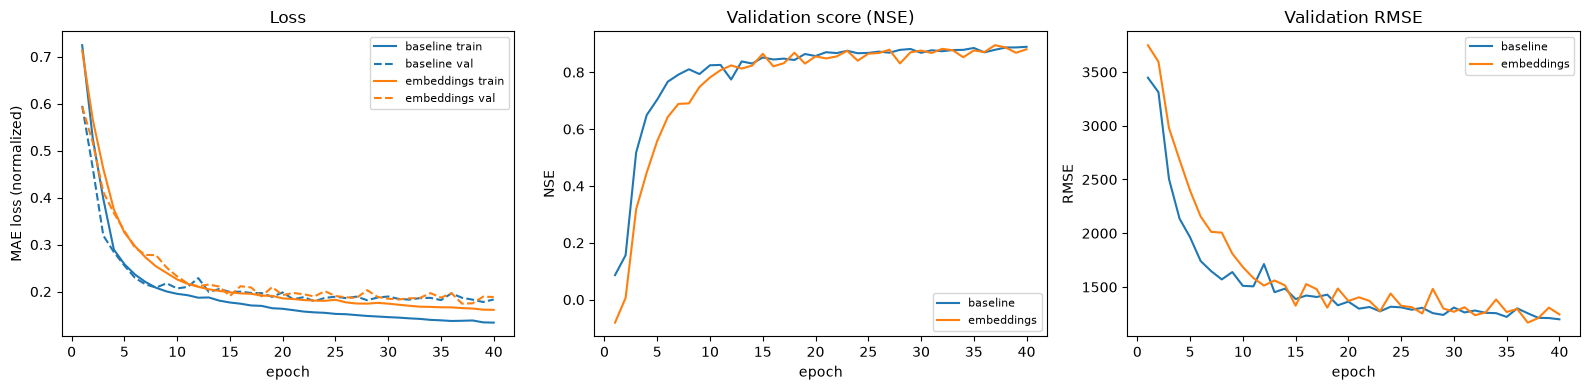

In [8]:
import matplotlib.pyplot as plt

models = [
    ('baseline', fc_base, 'tab:blue'),
    ('embeddings', fc_emb, 'tab:orange'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for label, m, color in models:
    ep = np.arange(1, len(m.loss_log) + 1)
    axes[0].plot(ep, m.loss_log, color=color, label=f'{label} train')
    axes[0].plot(ep, m.val_log_aggregated['mean']['loss'], color=color, linestyle='--', label=f'{label} val')
    axes[1].plot(ep, m.val_log_aggregated['mean']['val_score'], color=color, label=label)
    axes[2].plot(ep, m.val_log_aggregated['mean']['RMSE'], color=color, label=label)

axes[0].set_xlabel('epoch')
axes[0].set_ylabel('MAE loss (normalized)')
axes[0].set_title('Loss')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('epoch')
axes[1].set_ylabel('NSE')
axes[1].set_title('Validation score (NSE)')
axes[1].legend(fontsize=8)

axes[2].set_xlabel('epoch')
axes[2].set_ylabel('RMSE')
axes[2].set_title('Validation RMSE')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


## Evaluation on `test_source`

In [9]:
from src.data.timeseries_dataset import TimeSeriesDataset
from src.data.normalization import _read_1d_df

def evaluate(fc):
    preds = fc.predict(test_source, batch_size=256)
    y_pred = preds.squeeze(-1)  # (n_windows, horizon)
    ds = TimeSeriesDataset(
        sources=[test_source],
        seq_len=SEQ_LEN,
        horizon=HORIZON,
        historic_cols=HISTORIC_COLS,
        future_cols=FUTURE_COLS,
        norm_stats=fc.norm_stats,
        target_col=TARGET_COL,
    )
    t_values = np.array([t for _, t in ds._index])
    return y_pred, t_values

test_df = _read_1d_df(test_source)
y_pred_base, t_base = evaluate(fc_base)
y_pred_emb, t_emb = evaluate(fc_emb)
y_true = np.stack([test_df[TARGET_COL].values[t + SEQ_LEN : t + SEQ_LEN + HORIZON] for t in t_base])

print(f'Evaluated {y_true.shape[0]} windows over a {y_true.shape[1]}-day horizon on test_source')


Evaluated 1789 windows over a 7-day horizon on test_source


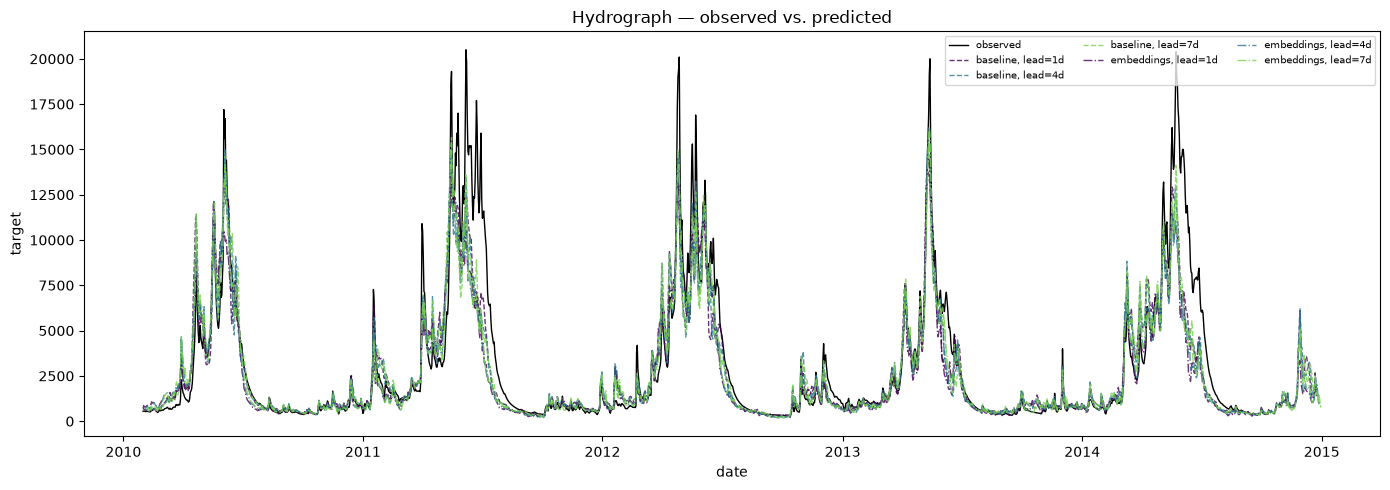

In [10]:
LEADS_TO_SHOW = [1, 4, 7]

model_preds = [
    ('baseline', y_pred_base, t_base, 'tab:blue', '--'),
    ('embeddings', y_pred_emb, t_emb, 'tab:orange', '-.'),
]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test_df.index[t_base + SEQ_LEN], y_true[:, 0], color='black', lw=1, label='observed')
colors = plt.cm.viridis(np.linspace(0, 0.8, len(LEADS_TO_SHOW)))
for label, y_p, t_vals, _, ls in model_preds:
    for lead, c in zip(LEADS_TO_SHOW, colors):
        dates = test_df.index[t_vals + SEQ_LEN + (lead - 1)]
        ax.plot(dates, y_p[:, lead - 1], color=c, lw=1, alpha=0.8, linestyle=ls, label=f'{label}, lead={lead}d')
ax.set_xlabel('date')
ax.set_ylabel(TARGET_COL)
ax.set_title('Hydrograph — observed vs. predicted')
ax.legend(ncol=3, fontsize=7)

plt.tight_layout()
plt.show()


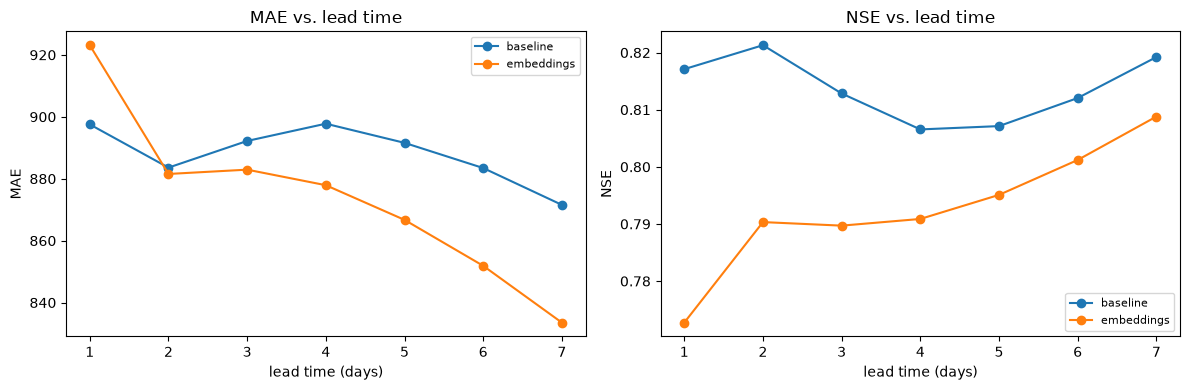

In [11]:
from src.utils.scores_and_losses import NSE

_nse_metric = NSE()

def nse(obs, pred):
    mask = ~np.isnan(obs) & ~np.isnan(pred)
    return _nse_metric(torch.tensor(pred[mask])[:, None], torch.tensor(obs[mask])[:, None]).item()

leads = np.arange(1, HORIZON + 1)
model_preds = [
    ('baseline', y_pred_base, 'tab:blue'),
    ('embeddings', y_pred_emb, 'tab:orange'),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, yp, color in model_preds:
    mae_per_lead = [np.nanmean(np.abs(y_true[:, i] - yp[:, i])) for i in range(HORIZON)]
    nse_per_lead = [nse(y_true[:, i], yp[:, i]) for i in range(HORIZON)]
    axes[0].plot(leads, mae_per_lead, marker='o', color=color, label=label)
    axes[1].plot(leads, nse_per_lead, marker='o', color=color, label=label)

axes[0].set_xlabel('lead time (days)')
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE vs. lead time')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('lead time (days)')
axes[1].set_ylabel('NSE')
axes[1].set_title('NSE vs. lead time')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()
